# Entrate Stato 2008-2024 - composizione per Titolo

Prima lettura sulla composizione delle entrate dello Stato con focus su 2008, 2020, 2024.

**Fonte**: MEF / RGS OpenBDAP — Rendiconto pubblicato entrate Stato  
**Dati**: [dataciviclab-clean](https://storage.googleapis.com/dataciviclab-clean/bdap_entrate_stato/2024/bdap_entrate_stato_2024_clean.parquet) (pubblico, CC BY)  
**Caveat**: le misure sono Previsioni Definitive CP/CS da rendiconto, non incasso effettivo.

In [1]:
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False

GCS_URL = 'https://storage.googleapis.com/dataciviclab-clean/bdap_entrate_stato/2024/bdap_entrate_stato_2024_clean.parquet'
ANNI_FOCUS = [2008, 2020, 2024]

df = pd.read_parquet(GCS_URL)
df = df.rename(columns={'esercizio_finanziario': 'anno'})
df.head()

,anno,codice_titolo,titolo,codice_natura,natura,codice_tipologia,tipologia,codice_provento,provento,previsioni_definitive_cp,previsioni_definitive_cs
0,2008,1,TITOLO I - ENTRATE TRIBUTARIE,1,Entrate ricorrenti,1,Imposta sui redditi,1,Entrate derivanti dall'attivita' ordinaria di ...,1.653603e+11,1.653603e+11
1,2008,1,TITOLO I - ENTRATE TRIBUTARIE,1,Entrate ricorrenti,1,Imposta sui redditi,2,Entrate derivanti dall'attivita' di accertamen...,9.675500e+09,1.986500e+09
2,2008,1,TITOLO I - ENTRATE TRIBUTARIE,1,Entrate ricorrenti,10,Lotto,1,Entrate derivanti dall'attivita' ordinaria di ...,5.911000e+09,5.911000e+09
3,2008,1,TITOLO I - ENTRATE TRIBUTARIE,1,Entrate ricorrenti,11,Imposte gravanti sui giochi,1,Entrate derivanti dall'attivita' ordinaria di ...,2.515000e+09,2.515000e+09
4,2008,1,TITOLO I - ENTRATE TRIBUTARIE,1,Entrate ricorrenti,12,Lotterie ed altri giochi,1,Entrate derivanti dall'attivita' ordinaria di ...,2.326000e+09,2.326000e+09


In [2]:
# Titolo breve: prende la parte dopo il trattino, es. "TITOLO I - ENTRATE TRIBUTARIE" -> "ENTRATE TRIBUTARIE"
df['titolo_breve'] = df['titolo'].str.split(' - ', n=1).str[-1].str.strip()

# Aggregazione per anno e titolo
agg = (
    df[df['anno'].isin(ANNI_FOCUS)]
    .groupby(['anno', 'titolo_breve'], as_index=False)['previsioni_definitive_cp']
    .sum()
)

# Quota sul totale annuo
totale_anno = agg.groupby('anno')['previsioni_definitive_cp'].transform('sum')
agg['quota_cp'] = agg['previsioni_definitive_cp'] / totale_anno
agg = agg.sort_values(['anno', 'titolo_breve'])
agg

,anno,titolo_breve,previsioni_definitive_cp,quota_cp
0,2008,ACCENSIONE DI PRESTITI,2.427237e+11,0.331429
1,2008,ALIENAZIONE ED AMMORTAMENTO DI BENI PATRIMONIA...,3.477914e+09,0.004749
2,2008,ENTRATE EXTRA-TRIBUTARIE,3.257165e+10,0.044475
3,2008,ENTRATE TRIBUTARIE,4.535811e+11,0.619346
4,2020,ACCENSIONE DI PRESTITI,5.298275e+11,0.496484
5,2020,ALIENAZIONE ED AMMORTAMENTO DI BENI PATRIMONIA...,4.183776e+09,0.003920
6,2020,ENTRATE EXTRA-TRIBUTARIE,7.022414e+10,0.065805
7,2020,ENTRATE TRIBUTARIE,4.629249e+11,0.433791
8,2024,ACCENSIONE DI PRESTITI,5.311784e+11,0.421889
9,2024,ALIENAZIONE ED AMMORTAMENTO DI BENI PATRIMONIA...,3.000947e+09,0.002384


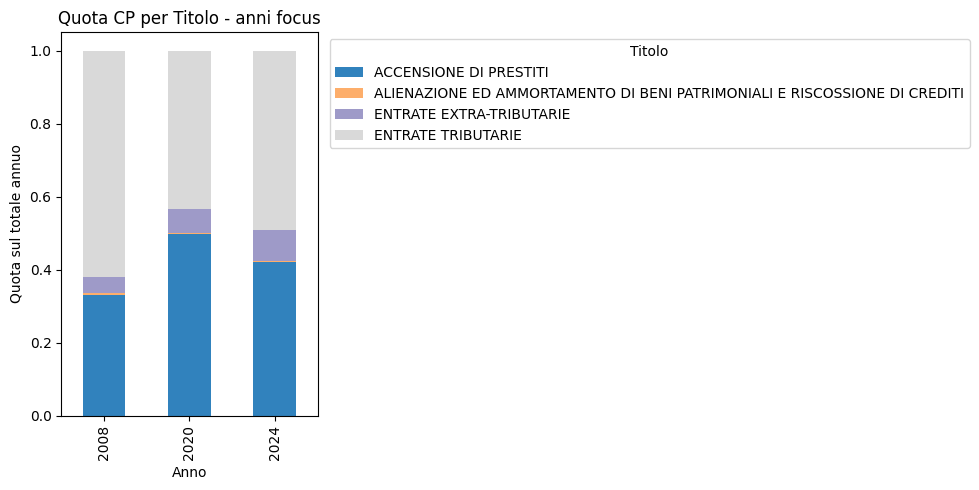

In [3]:
pivot = agg.pivot(index='anno', columns='titolo_breve', values='quota_cp').sort_index()
if HAS_MATPLOTLIB:
    ax = pivot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20c')
    ax.set_title('Quota CP per Titolo - anni focus')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Quota sul totale annuo')
    ax.legend(title='Titolo', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    pivot

In [4]:
confronto = agg[agg['titolo_breve'].isin(['ENTRATE TRIBUTARIE', 'ACCENSIONE DI PRESTITI'])].copy()
confronto = confronto.sort_values(['anno', 'titolo_breve'])
confronto

,anno,titolo_breve,previsioni_definitive_cp,quota_cp
0,2008,ACCENSIONE DI PRESTITI,2.427237e+11,0.331429
3,2008,ENTRATE TRIBUTARIE,4.535811e+11,0.619346
4,2020,ACCENSIONE DI PRESTITI,5.298275e+11,0.496484
7,2020,ENTRATE TRIBUTARIE,4.629249e+11,0.433791
8,2024,ACCENSIONE DI PRESTITI,5.311784e+11,0.421889
11,2024,ENTRATE TRIBUTARIE,6.202282e+11,0.492617


## Prima lettura

Sulla quota CP aggregata per i due titoli principali:

| Anno | Entrate tributarie | Accensione prestiti |
|------|--------------------|--------------------|
| 2008 | ~62%               | ~33%               |
| 2020 | ~43%               | ~50%               |
| 2024 | ~49%               | ~42%               |

Nelle due crisi principali del periodo (2008-2009 e 2020) la composizione si sposta in modo marcato verso l'accensione di prestiti. Nel 2024 si osserva un parziale rientro, con le entrate tributarie che recuperano quota.

**Caveat principale**: le misure sono Previsioni Definitive da rendiconto (CP = Competenza Propria), non incassi effettivi. La lettura riguarda il perimetro autorizzato a consuntivo, non la riscossione reale.

**Cosa non possiamo ancora dire**:
- se la variazione dipenda da riclassificazioni contabili in alcuni anni
- se il fenomeno sia una scelta strutturale o una risposta una tantum alle crisi
- effetti su finanza pubblica allargata (perimetro solo Stato centrale)